Notebook 8: Class-Weighted Cross-Lingual Runs

Weighting is uniform across both directions: [1.0, 2.0]

Setup

In [1]:
import os, sys
from google.colab import drive

drive.mount('/content/drive')
REPO= "Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-"
DRIVE= f'/content/drive/MyDrive/{REPO}'

!git -C "{DRIVE}" pull --ff-only
sys.path.insert(0, DRIVE)
os.chdir(DRIVE)
DATA_DIR = f'{DRIVE}/data'
D =f'{DRIVE}/bilingual results'
M='/content/drive/MyDrive/cyberbullying_models'
FIG = f'{D}/figures'
for p in (M, FIG):
    os.makedirs(p, exist_ok=True)

print("working dir ->", os.getcwd())
print("results->", D)
print("models->", M)


Mounted at /content/drive
Already up to date.
working dir -> /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-
results-> /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results
models-> /content/drive/MyDrive/cyberbullying_models


In [2]:
import pandas as pd, numpy as np, pickle, json, torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, EarlyStoppingCallback)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
with open(f'{DATA_DIR}/english_transformer_data.pkl', 'rb') as f: english_data = pickle.load(f)
with open(f'{DATA_DIR}/spanish_transformer_data.pkl', 'rb') as f: spanish_data = pickle.load(f)

english_train_texts, english_train_labels=english_data['train_texts'],english_data['train_labels']
english_val_texts,english_val_labels= english_data['val_texts'],english_data['val_labels']
english_test_texts,english_test_labels= english_data['test_texts'],english_data['test_labels']

spanish_train_texts,spanish_train_labels =spanish_data['train_texts'],spanish_data['train_labels']
spanish_val_texts,spanish_val_labels= spanish_data['val_texts'],spanish_data['val_labels']
spanish_test_texts,spanish_test_labels = spanish_data['test_texts'], spanish_data['test_labels']

print(f"EN train {len(english_train_texts)}  val {len(english_val_texts)}  test {len(english_test_texts)}")
print(f"ES train {len(spanish_train_texts)}  val {len(spanish_val_texts)}  test {len(spanish_test_texts)}")

EN train 45899  val 9839  test 9843
ES train 19325  val 4141  test 4141


 Helpers



In [4]:
class CyberbullyingDataset(Dataset):
    def __init__(self,encodings, labels):
        self.encodings,self.labels = encodings, labels
    def __getitem__(self, idx):
        item ={k: v[idx] for k, v in self.encodings.items()}
        item['labels']= torch.tensor(self.labels[idx])
        return item
    def __len__(self):return len(self.labels)


def make_weighted_trainer(class_weights):
    w=torch.tensor(class_weights, dtype=torch.float)
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels =inputs.get("labels")
            outputs= model(**inputs)
            logits =outputs.get("logits")
            loss =nn.CrossEntropyLoss(weight=w.to(logits.device))(logits, labels)
            return (loss, outputs) if return_outputs else loss
    return WeightedTrainer


def compute_metrics(eval_pred):
    predictions,labels= eval_pred
    predictions =np.argmax(predictions, axis=1)
    return {'accuracy': accuracy_score(labels, predictions),
            'f1':f1_score(labels, predictions, average='macro'),
            'precision': precision_score(labels, predictions, average='macro'),
            'recall':recall_score(labels, predictions, average='macro')}


def save_run(tag, preds, raw, labels, texts):
    raw =np.asarray(raw, dtype=np.float64)
    probs =softmax(raw, axis=1) if not np.allclose(raw.sum(1), 1, atol=1e-3) else raw
    assert probs[:, 1].max() > 0.75, f"{tag}: probabilities look softmaxed twice"
    np.save(f'{D}/{tag}_preds.npy', np.asarray(preds))
    np.save(f'{D}/{tag}_probs.npy',probs.astype(np.float32))
    np.save(f'{D}/{tag}_labels.npy',np.asarray(labels))
    rep = classification_report(labels, preds, target_names=['Non-Abusive', 'Abusive'], output_dict=True, digits=4)
    json.dump(rep, open(f'{D}/{tag}_metrics.json', 'w'), indent=2)
    pd.DataFrame({'text': texts, 'true': labels, 'pred': preds,'prob_abusive': probs[:, 1]}).to_csv(f'{D}/{tag}_samples.csv', index=False)
    print(f"{tag:26s} n={len(preds):6d} macroF1 {rep['macro avg']['f1-score']:.4f} "
          f"NonAb {rep['Non-Abusive']['recall']:.4f} Ab {rep['Abusive']['recall']:.4f}")
    return rep


CLASS_WEIGHTS = [1.0, 2.0]
def run_weighted(model_key, checkpoint, direction):
    if direction == 'en2es':
        tr_x,tr_y =english_train_texts, english_train_labels
        va_x, va_y = english_val_texts,english_val_labels
        te_x,te_y =spanish_test_texts,spanish_test_labels
    elif direction == 'es2en':
        tr_x,tr_y = spanish_train_texts, spanish_train_labels
        va_x, va_y= spanish_val_texts,spanish_val_labels
        te_x, te_y = english_test_texts,english_test_labels
    else:
        raise ValueError(direction)

    tag = f'{model_key}_{direction}_weighted'
    print(f"\n{'='*66}\n  {tag}   weights {CLASS_WEIGHTS}\n{'='*66}")

    tok = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
    enc = lambda xs: tok(xs, truncation=True, padding=True, max_length=128, return_tensors='pt')

    args =TrainingArguments(
        output_dir=f'./results/{tag}', num_train_epochs=3,
        per_device_train_batch_size=16, per_device_eval_batch_size=16,
        learning_rate=2e-5, warmup_steps=500, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="f1",
        greater_is_better=True, seed=42)

    trainer =make_weighted_trainer(CLASS_WEIGHTS)(
        model=model,args=args,
        train_dataset=CyberbullyingDataset(enc(tr_x), tr_y),
        eval_dataset=CyberbullyingDataset(enc(va_x), va_y),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
    trainer.train()

    out= trainer.predict(CyberbullyingDataset(enc(te_x), te_y))
    preds= np.argmax(out.predictions, axis=1)
    rep =save_run(tag, preds, out.predictions, te_y, te_x)
    print(classification_report(te_y, preds, target_names=['Non-Abusive', 'Abusive'], digits=4))

    model.save_pretrained(f'{M}/{tag}')
    tok.save_pretrained(f'{M}/{tag}')
    return rep

print("helpers ready | class weights:", CLASS_WEIGHTS)

helpers ready | class weights: [1.0, 2.0]


## Runs

XLM-R first. It transfers best in both directions, so it carries the most
residual signal for reweighting to exploit; if reweighting fails there it fails
everywhere. Each run is roughly 40 minutes for ES→EN and 75 for EN→ES.

Run only the cells you have compute for. Section 4.7 can report a subset with the
limitation stated, and the comparison table below fills in whatever exists.

In [ ]:
CHECKPOINTS = {'xlmr':'xlm-roberta-base','mbert':'bert-base-multilingual-cased','distilbert': 'distilbert-base-multilingual-cased'}

# Completed in an earlier session (session reset due to Colab limits); the result is read from the saved metrics in the comparison below.
_ = run_weighted('xlmr', CHECKPOINTS['xlmr'], 'es2en')


In [ ]:
_ = run_weighted('xlmr', CHECKPOINTS['xlmr'], 'en2es')


  xlmr_en2es_weighted   weights [1.0, 2.0]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.194277,0.202982,0.909035,0.908811,0.913006,0.909001
2,0.168414,0.193514,0.923874,0.923861,0.924146,0.923865
3,0.149009,0.195825,0.924179,0.924112,0.925632,0.924159


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

xlmr_en2es_weighted        n=  4141 macroF1 0.5075 NonAb 0.7479 Ab 0.3135
              precision    recall  f1-score   support

 Non-Abusive     0.5215    0.7479    0.6146      2071
     Abusive     0.5542    0.3135    0.4005      2070

    accuracy                         0.5308      4141
   macro avg     0.5379    0.5307    0.5075      4141
weighted avg     0.5379    0.5308    0.5076      4141



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# The two DistilBERT runs were completed in an earlier session (session reset due to Colab limits); their results are read from the saved metrics in the comparison below.
_ = run_weighted('mbert',      CHECKPOINTS['mbert'],      'es2en')
_ = run_weighted('mbert',      CHECKPOINTS['mbert'],      'en2es')
_ = run_weighted('distilbert', CHECKPOINTS['distilbert'], 'es2en')
_ = run_weighted('distilbert', CHECKPOINTS['distilbert'], 'en2es')


  mbert_es2en_weighted   weights [1.0, 2.0]


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

mbert_en2es_weighted       n=  4141 macroF1 0.4276 NonAb 0.9387 Ab 0.1121
              precision    recall  f1-score   support

 Non-Abusive     0.5140    0.9387    0.6643      2071
     Abusive     0.6462    0.1121    0.1910      2070

    accuracy                         0.5255      4141
   macro avg     0.5801    0.5254    0.4276      4141
weighted avg     0.5801    0.5255    0.4277      4141



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Comparison


In [ ]:
def read(tag):
    p =f'{D}/{tag}_metrics.json'
    if not os.path.exists(p): return None
    d =json.load(open(p))
    return {'f1': d['macro avg']['f1-score'],'non_ab': d['Non-Abusive']['recall'],
            'abusive': d['Abusive']['recall']}

LABEL ={'xlmr': 'XLM-R', 'mbert': 'mBERT', 'distilbert': 'DistilBERT'}
ARROW={'en2es': 'EN→ES', 'es2en': 'ES→EN'}

rows =[]
for m in ['distilbert', 'mbert', 'xlmr']:
    for d_ in ['en2es', 'es2en']:
        u, w = read(f'{m}_{d_}'), read(f'{m}_{d_}_weighted')
        if u is None or w is None:
            continue
        rows.append({
            'Model': LABEL[m], 'Direction': ARROW[d_],
            'F1 before': round(u['f1'], 4),'F1 after': round(w['f1'], 4),
            'F1 change': f"{100*(w['f1']-u['f1']):+.2f} pp",
            'Abusive before': round(u['abusive'], 4), 'Abusive after': round(w['abusive'], 4),
            'Abusive change': f"{100*(w['abusive']-u['abusive']):+.2f} pp",
            'Non-Ab before': round(u['non_ab'], 4),'Non-Ab after': round(w['non_ab'], 4),
        })

if rows:
    comp= pd.DataFrame(rows)
    comp.to_csv(f'{D}/weighted_vs_unweighted.csv', index=False)
    print(comp.to_string(index=False))
else:
    print("No completed weighted runs yet.")

done =[f"{LABEL[m]} {ARROW[d_]}" for m in ['distilbert','mbert','xlmr'] for d_ in ['en2es','es2en']
        if read(f'{m}_{d_}_weighted') is None]
if done:
    print("\nnot yet run:", ", ".join(done))

     Model Direction  F1 before  F1 after F1 change  Abusive before  Abusive after Abusive change  Non-Ab before  Non-Ab after
DistilBERT     EN→ES     0.4301    0.4559  +2.58 pp          0.1169         0.1657       +4.88 pp         0.9329        0.8880
DistilBERT     ES→EN     0.5396    0.5665  +2.69 pp          0.2790         0.3289       +4.98 pp         0.8843        0.8666
     mBERT     EN→ES     0.4077    0.4276  +2.00 pp          0.0957         0.1121       +1.64 pp         0.9218        0.9387
     mBERT     ES→EN     0.5456    0.5597  +1.41 pp          0.2794         0.3032       +2.38 pp         0.8985        0.8922
     XLM-R     EN→ES     0.4942    0.5075  +1.33 pp          0.2783         0.3135       +3.53 pp         0.7716        0.7479
     XLM-R     ES→EN     0.6313    0.6500  +1.87 pp          0.4190         0.4678       +4.88 pp         0.8831        0.8587


Plot

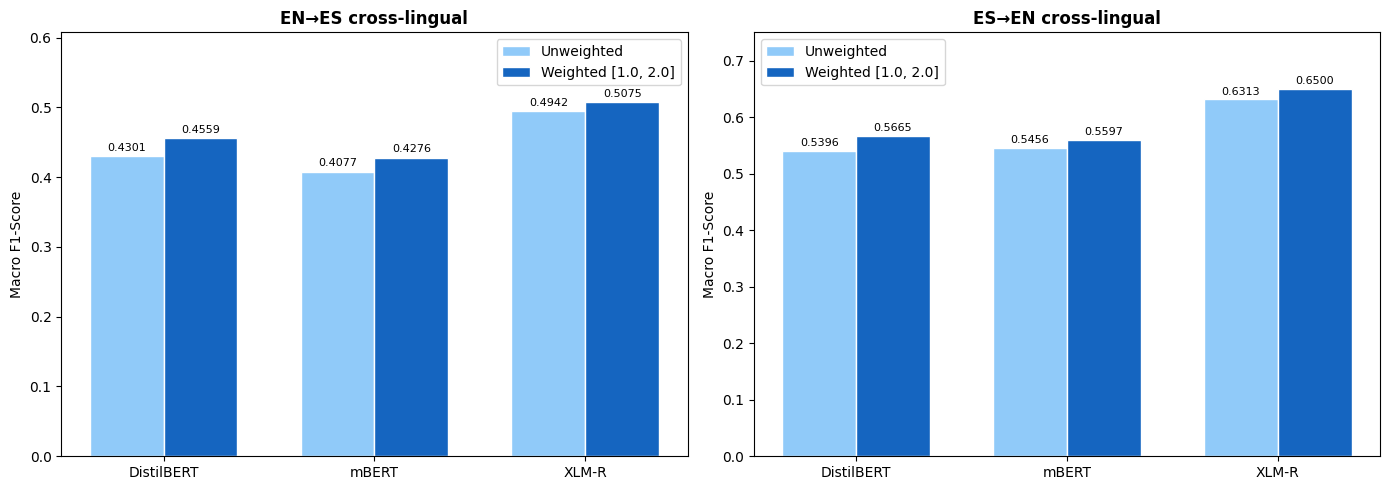

In [ ]:
if rows:
    fig, axes= plt.subplots(1, 2, figsize=(14, 5))
    for ax, d_ in zip(axes, ['en2es', 'es2en']):
        sub =comp[comp['Direction']== ARROW[d_]]
        if not len(sub):
            ax.set_visible(False); continue
        x =np.arange(len(sub)); w = 0.35
        b1= ax.bar(x - w/2, sub['F1 before'], w, label='Unweighted',
                    color='#90CAF9', edgecolor='white')
        b2 =ax.bar(x + w/2, sub['F1 after'], w, label='Weighted [1.0, 2.0]',color='#1565C0', edgecolor='white')
        ax.set_title(f'{ARROW[d_]} cross-lingual', fontsize=12, fontweight='bold')
        ax.set_ylabel('Macro F1-Score'); ax.set_xticks(x)
        ax.set_xticklabels(sub['Model']); ax.legend()
        ax.set_ylim(0, max(sub[['F1 before','F1 after']].max()) + 0.1)
        for b in list(b1) + list(b2):
            ax.text(b.get_x() +b.get_width()/2, b.get_height() + 0.005,
                    f'{b.get_height():.4f}', ha='center',va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{FIG}/weighted_vs_unweighted.png',dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
FALLBACK = {'distilbert_en_only': 0.9262}
def f1(tag):
    p= f'{D}/{tag}_metrics.json'
    if os.path.exists(p):
        return json.load(open(p))['macro avg']['f1-score']
    return FALLBACK.get(tag)

RUNS = [('distilbert', 'en2es', 'distilbert_es_only'),
        ('mbert','en2es', 'mbert_es_only'),
        ('xlmr','en2es', 'xlmr_es_only'),
        ('distilbert', 'es2en', 'distilbert_en_only'),
        ('mbert','es2en', 'mbert_en_only'),
        ('xlmr','es2en', 'xlmr_en_only')]

pcts =[]
for m,d,ceil_tag in RUNS:
    base,weighted, ceiling= f1(f'{m}_{d}'), f1(f'{m}_{d}_weighted'), f1(ceil_tag)
    assert None not in (base, weighted, ceiling), f'missing file for {m} {d}'
    pct=100 *(weighted - base)/(ceiling - base)
    pcts.append(pct)
    print(f"  {m:11s} {d}  {base:.4f} -> {weighted:.4f}  ceiling {ceiling:.4f}   {pct:5.2f}%")

W_LO,W_HI= min(pcts),max(pcts)
print(f"\n  class weighting : {W_LO:.1f}% to {W_HI:.1f}%   (chapter says 3.4% to 7.0%)")
print(f"  500 examples    : {LORA:.1f}%              (chapter says 73.7%)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  distilbert  en2es  0.4301 -> 0.4559  ceiling 0.8684    5.90%
  mbert       en2es  0.4077 -> 0.4276  ceiling 0.8773    4.25%
  xlmr        en2es  0.4942 -> 0.5075  ceiling 0.8860    3.41%
  distilbert  es2en  0.5396 -> 0.5665  ceiling 0.9262    6.96%
  mbert       es2en  0.5456 -> 0.5597  ceiling 0.9257    3.71%
  xlmr        es2en  0.6313 -> 0.6500  ceiling 0.9294    6.27%

  class weighting : 3.4% to 7.0%   (chapter says 3.4% to 7.0%)
  500 examples    : 73.6%              (chapter says 73.7%)


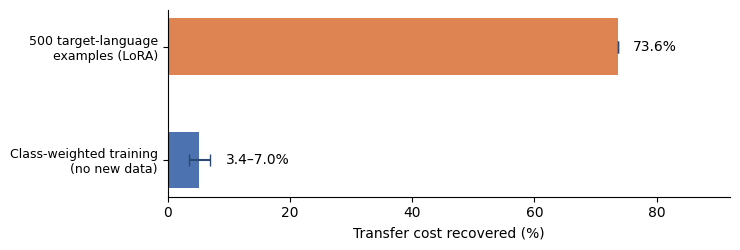

saved: /content/drive/MyDrive/Cyberbullying-Detection-in-Bilingual-English-Spanish-Text-A-Comparative-Study-/bilingual results/figures/fig_5_1_interventions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
mid, err= (W_LO + W_HI)/2,(W_HI - W_LO) /2
fig, ax =plt.subplots(figsize=(7.5, 2.6))
ax.barh([0, 1],[mid, LORA], height=0.5, color=['#4C72B0', '#DD8452'],xerr=[[err, 0],[err, 0]], error_kw={'ecolor': '#2A4A73', 'capsize': 4})
ax.text(W_HI + 2.5, 0,f'{W_LO:.1f}–{W_HI:.1f}%', va='center', fontsize=10)
ax.text(LORA + 2.5, 1,f'{LORA:.1f}%', va='center', fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Class-weighted training\n(no new data)','500 target-language\nexamples (LoRA)'], fontsize=9)
ax.set_xlabel('Transfer cost recovered (%)')
ax.set_xlim(0, 92)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

out = f'{FIG}/fig_5_1_interventions.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', out)
files.download(out)